# Multiple Linear Regression – Salary Prediction 💼📊

## Project Overview
This project demonstrates the implementation of **Multiple Linear Regression**
to predict employee salaries based on the following factors:

- Years of Experience  
- Test Score (out of 10)  
- Interview Score (out of 10)

The workflow includes:
1. Data loading
2. Data cleaning & preprocessing
3. Feature engineering
4. Model training using scikit-learn
5. Salary prediction

This project is beginner-friendly and demonstrates real-world data preprocessing
along with machine learning model building.


In [39]:
! pip install word2number

In [40]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from word2number import w2n
from sklearn.linear_model import LinearRegression


In [41]:
# Load the dataset
df = pd.read_csv("hiring.csv")

# Display dataset
df


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [42]:
# Replace missing experience values with 'zero'
df["experience"].fillna("zero", inplace=True)

# Convert text numbers into numeric values
df["experience"] = df["experience"].apply(w2n.word_to_num)

df


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [43]:
# Calculate mean of test scores
mean_test_score = df["test_score(out of 10)"].mean()

# Fill missing test scores with mean value
df["test_score(out of 10)"].fillna(mean_test_score, inplace=True)

df


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.000000,9,50000
1,0,8.000000,6,45000
2,5,6.000000,7,60000
3,2,10.000000,10,65000
4,7,9.000000,6,70000
5,3,7.000000,10,62000
6,10,7.857143,7,72000
7,11,7.000000,8,80000


In [44]:
# Check if any missing values remain
df.isnull().sum()


,0
experience,0
test_score(out of 10),0
interview_score(out of 10),0
salary($),0


In [45]:
# Display descriptive statistics
df.describe()


,experience,test_score(out of 10),interview_score(out of 10),salary($)
count,8.00000,8.000000,8.000000,8.00000
mean,4.75000,7.857143,7.875000,63000.00000
std,4.26782,1.245400,1.642081,11501.55269
min,0.00000,6.000000,6.000000,45000.00000
25%,1.50000,7.000000,6.750000,57500.00000
50%,4.00000,7.928571,7.500000,63500.00000
75%,7.75000,8.250000,9.250000,70500.00000
max,11.00000,10.000000,10.000000,80000.00000


In [46]:
# Independent variables (features)
input_ = df.drop(columns="salary($)")

# Dependent variable (target)
output_ = df["salary($)"]

output_



,salary($)
0,50000
1,45000
2,60000
3,65000
4,70000
5,62000
6,72000
7,80000


In [47]:
# Initialize Linear Regression model
model = LinearRegression()

In [48]:
# Train the model using the dataset
model.fit(input_, output_)


LinearRegression()

In [49]:
# Display model coefficients
print("Model Coefficients:", model.coef_)

# Display model intercept
print("Model Intercept:", model.intercept_)


Model Coefficients: [2827.63404314 1912.93803053 2196.9753141 ]
Model Intercept: 17237.330313727172


In [50]:
predicted = model.predict(input_)
predicted

array([52313.61238494, 45722.68644263, 58231.95591138, 63991.7318464 ,
       67429.06277517, 61080.55179794, 75922.72532666, 79307.67351488])

In [51]:
# Predict salary for:
# Experience = 5 years
# Test Score = 9
# Interview Score = 7

prediction = model.predict([[5, 9, 7]])

print(f"Predicted Salary: ${int(prediction[0])}")


Predicted Salary: $63970


In [52]:
df["predicted"] = predicted
df

,experience,test_score(out of 10),interview_score(out of 10),salary($),predicted
0,0,8.000000,9,50000,52313.612385
1,0,8.000000,6,45000,45722.686443
2,5,6.000000,7,60000,58231.955911
3,2,10.000000,10,65000,63991.731846
4,7,9.000000,6,70000,67429.062775
5,3,7.000000,10,62000,61080.551798
6,10,7.857143,7,72000,75922.725327
7,11,7.000000,8,80000,79307.673515


In [53]:
input_.head(1)

,experience,test_score(out of 10),interview_score(out of 10)
0,0,8.0,9


In [54]:
df["experience"]

,experience
0,0
1,0
2,5
3,2
4,7
5,3
6,10
7,11


In [55]:
# salary prediction
exp = float(input("Experience: "))
t_score = float(input("Test score: "))
i_score = float(input("Interview score: "))

prediction = model.predict([[exp, t_score, i_score]])
print("predicted Salary $ :", prediction[0].round(decimals=2))

Experience: 3.4
Test score: 5.6
Interview score: 3.2
predicted Salary $ : 44594.06


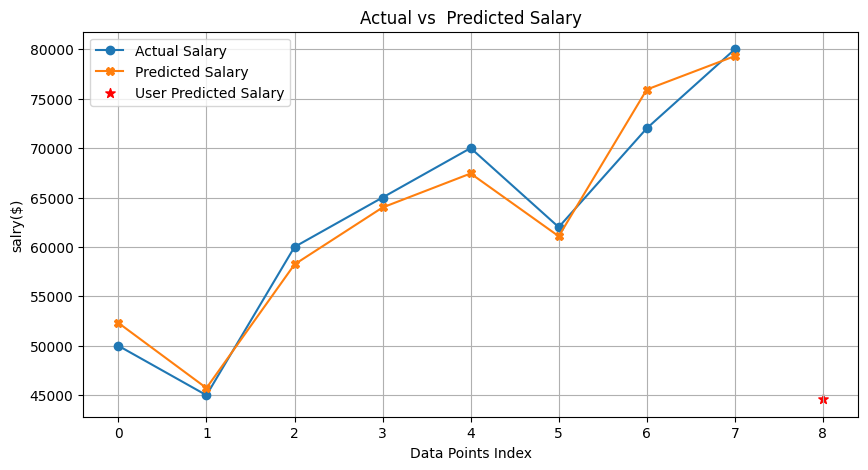

In [58]:
plt.figure(figsize=(10,5))
plt.plot(df.index,output_,label="Actual Salary",marker = "o")
plt.plot(df.index,predicted,label="Predicted Salary",marker = "X")

plt.scatter(len(df),prediction,color="red",label="User Predicted Salary",s=50, marker="*")

plt.xlabel("Data Points Index")
plt.ylabel("salry($)")
plt.title("Actual vs  Predicted Salary")
plt.legend()
plt.grid(True)
plt.show()